AUC performance of all models comparing TCGA Test vs. CGGA Validation.

First few rows of the dataset:
         Model      Pipeline    Dataset  Threshold     AUC  Accuracy  \
0  HeteroGATv2  No Balancing  TCGA Test      0.502  0.8952    0.7976   
1  HeteroGATv2  No Balancing       CGGA      0.502  0.7732    0.6364   
2        MOGAT  No Balancing  TCGA Test      0.554  0.9206    0.8512   
3        MOGAT  No Balancing       CGGA      0.554  0.7688    0.6748   
4     HyperTMO  No Balancing  TCGA Test      0.520  0.8245    0.5655   

   Precision  Recall_1  Recall_0      F1  
0     0.7143    0.8571    0.7551  0.7792  
1     0.4944    0.8725    0.5054  0.6312  
2     0.7848    0.8857    0.8265  0.8322  
3     0.5287    0.8137    0.5978  0.6409  
4     0.4894    0.9857    0.2653  0.6540  

Dataset shape: (56, 10)

Unique models: <StringArray>
['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']
Length: 7, dtype: str

Unique pipelines: <StringArray>
['No Balancing', 'SMOTE', 'CTGAN', 'ROS']
Length: 4, dtype: str

Models: <StringArray>
['Het

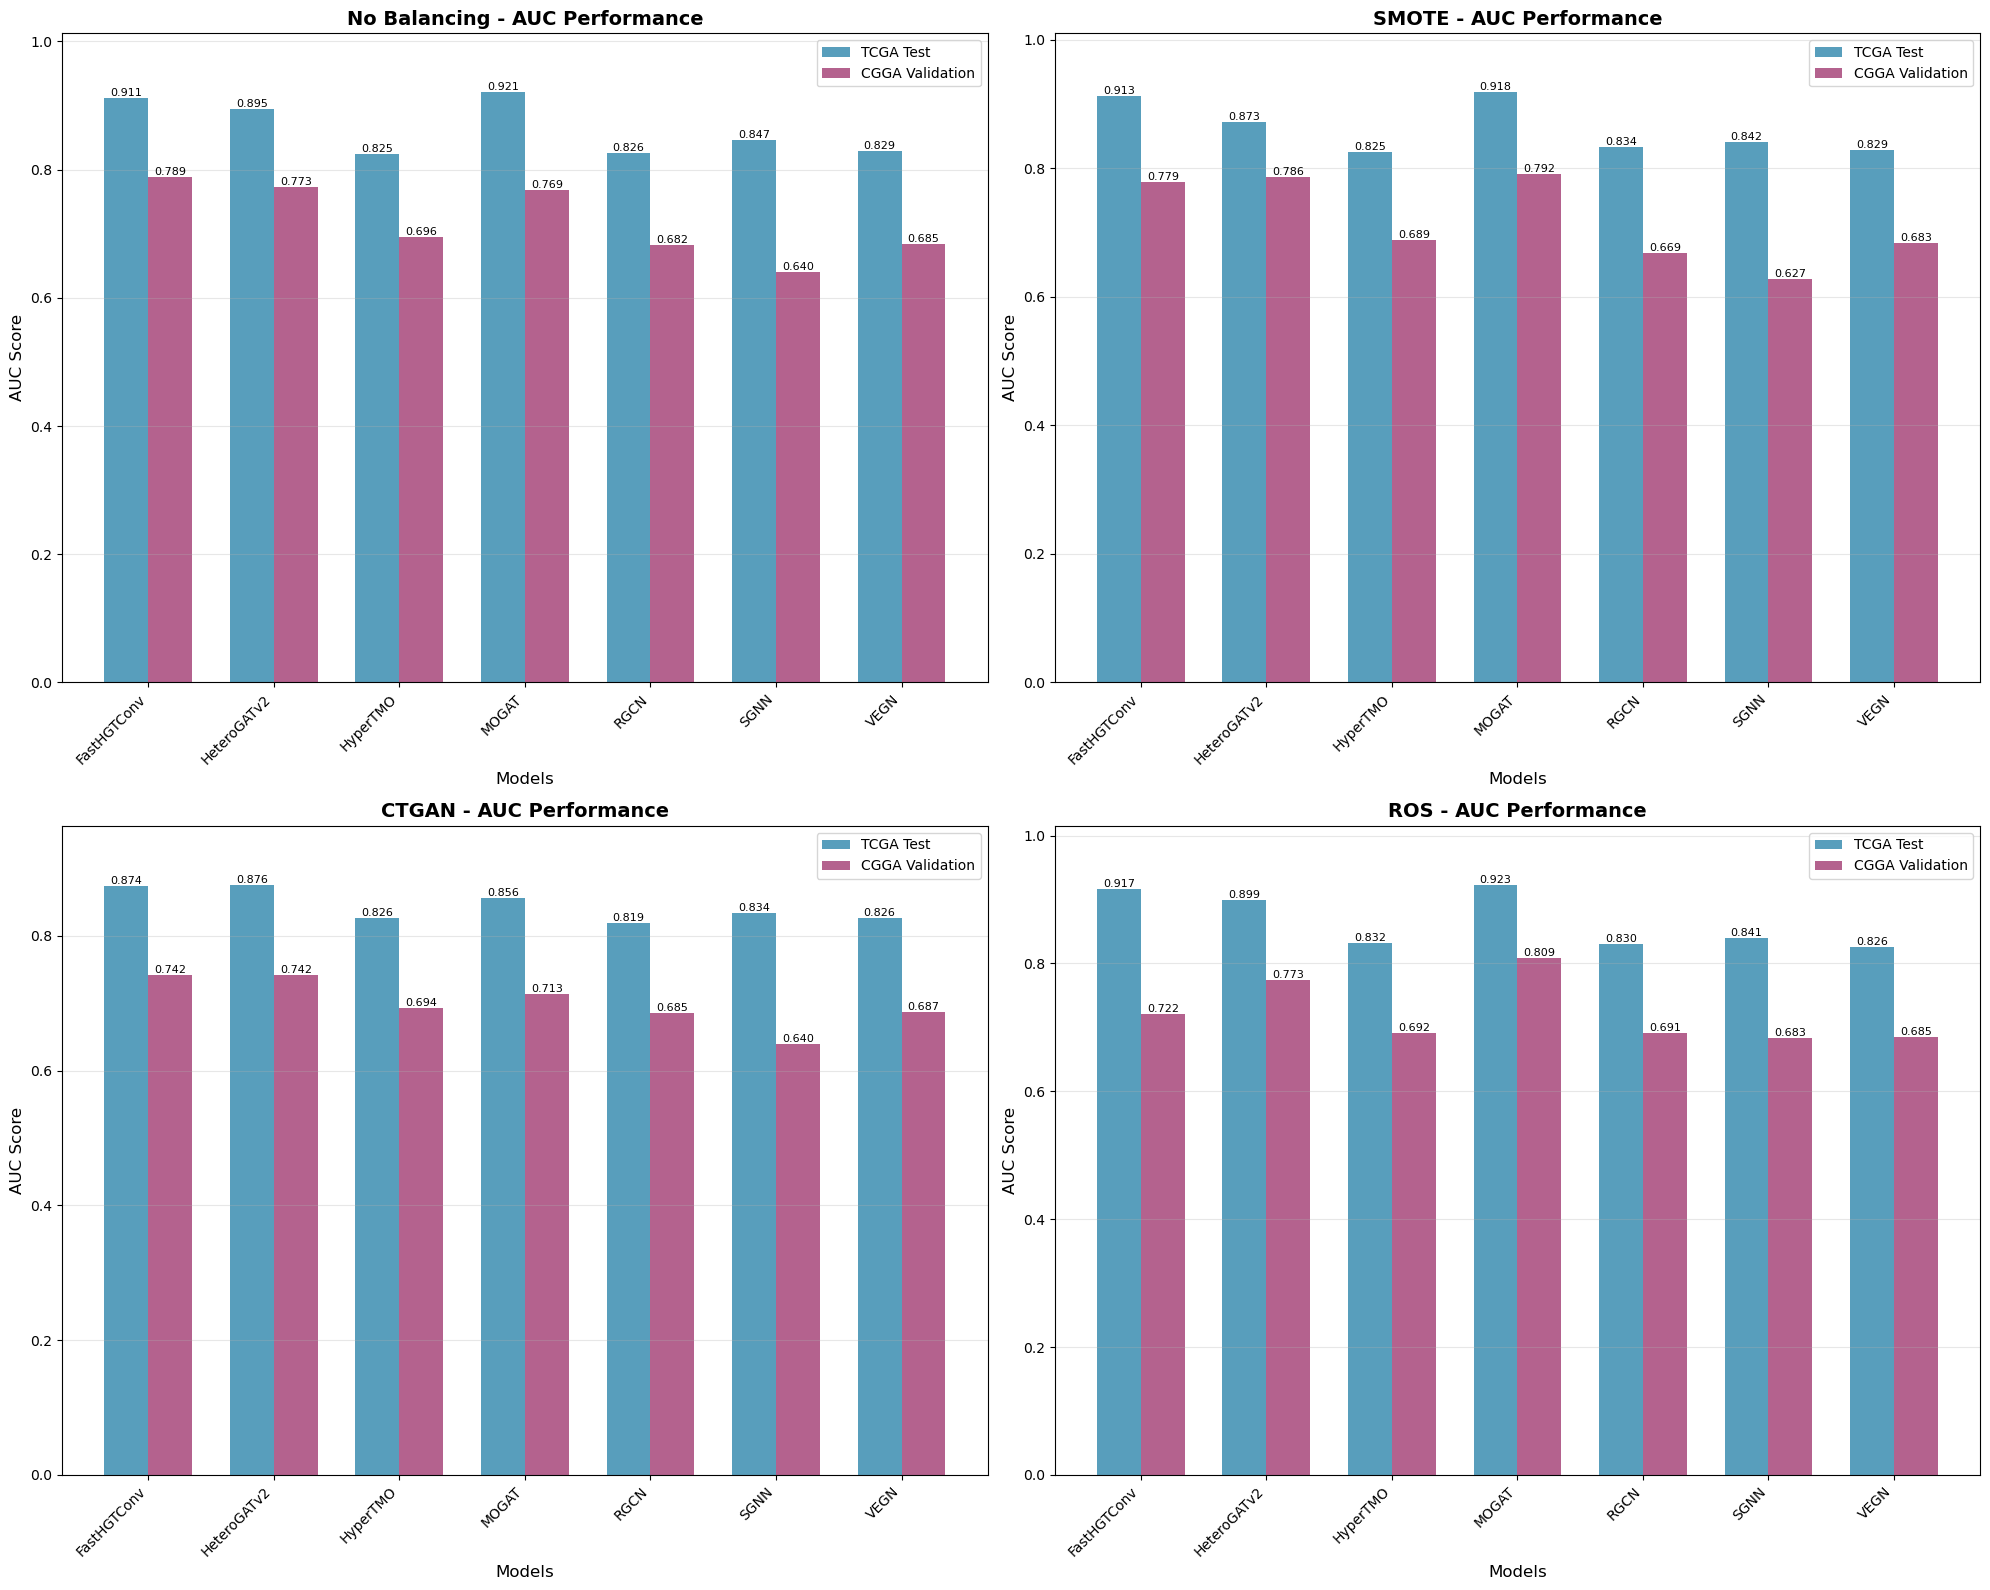


2. Plotting F1-score comparison...


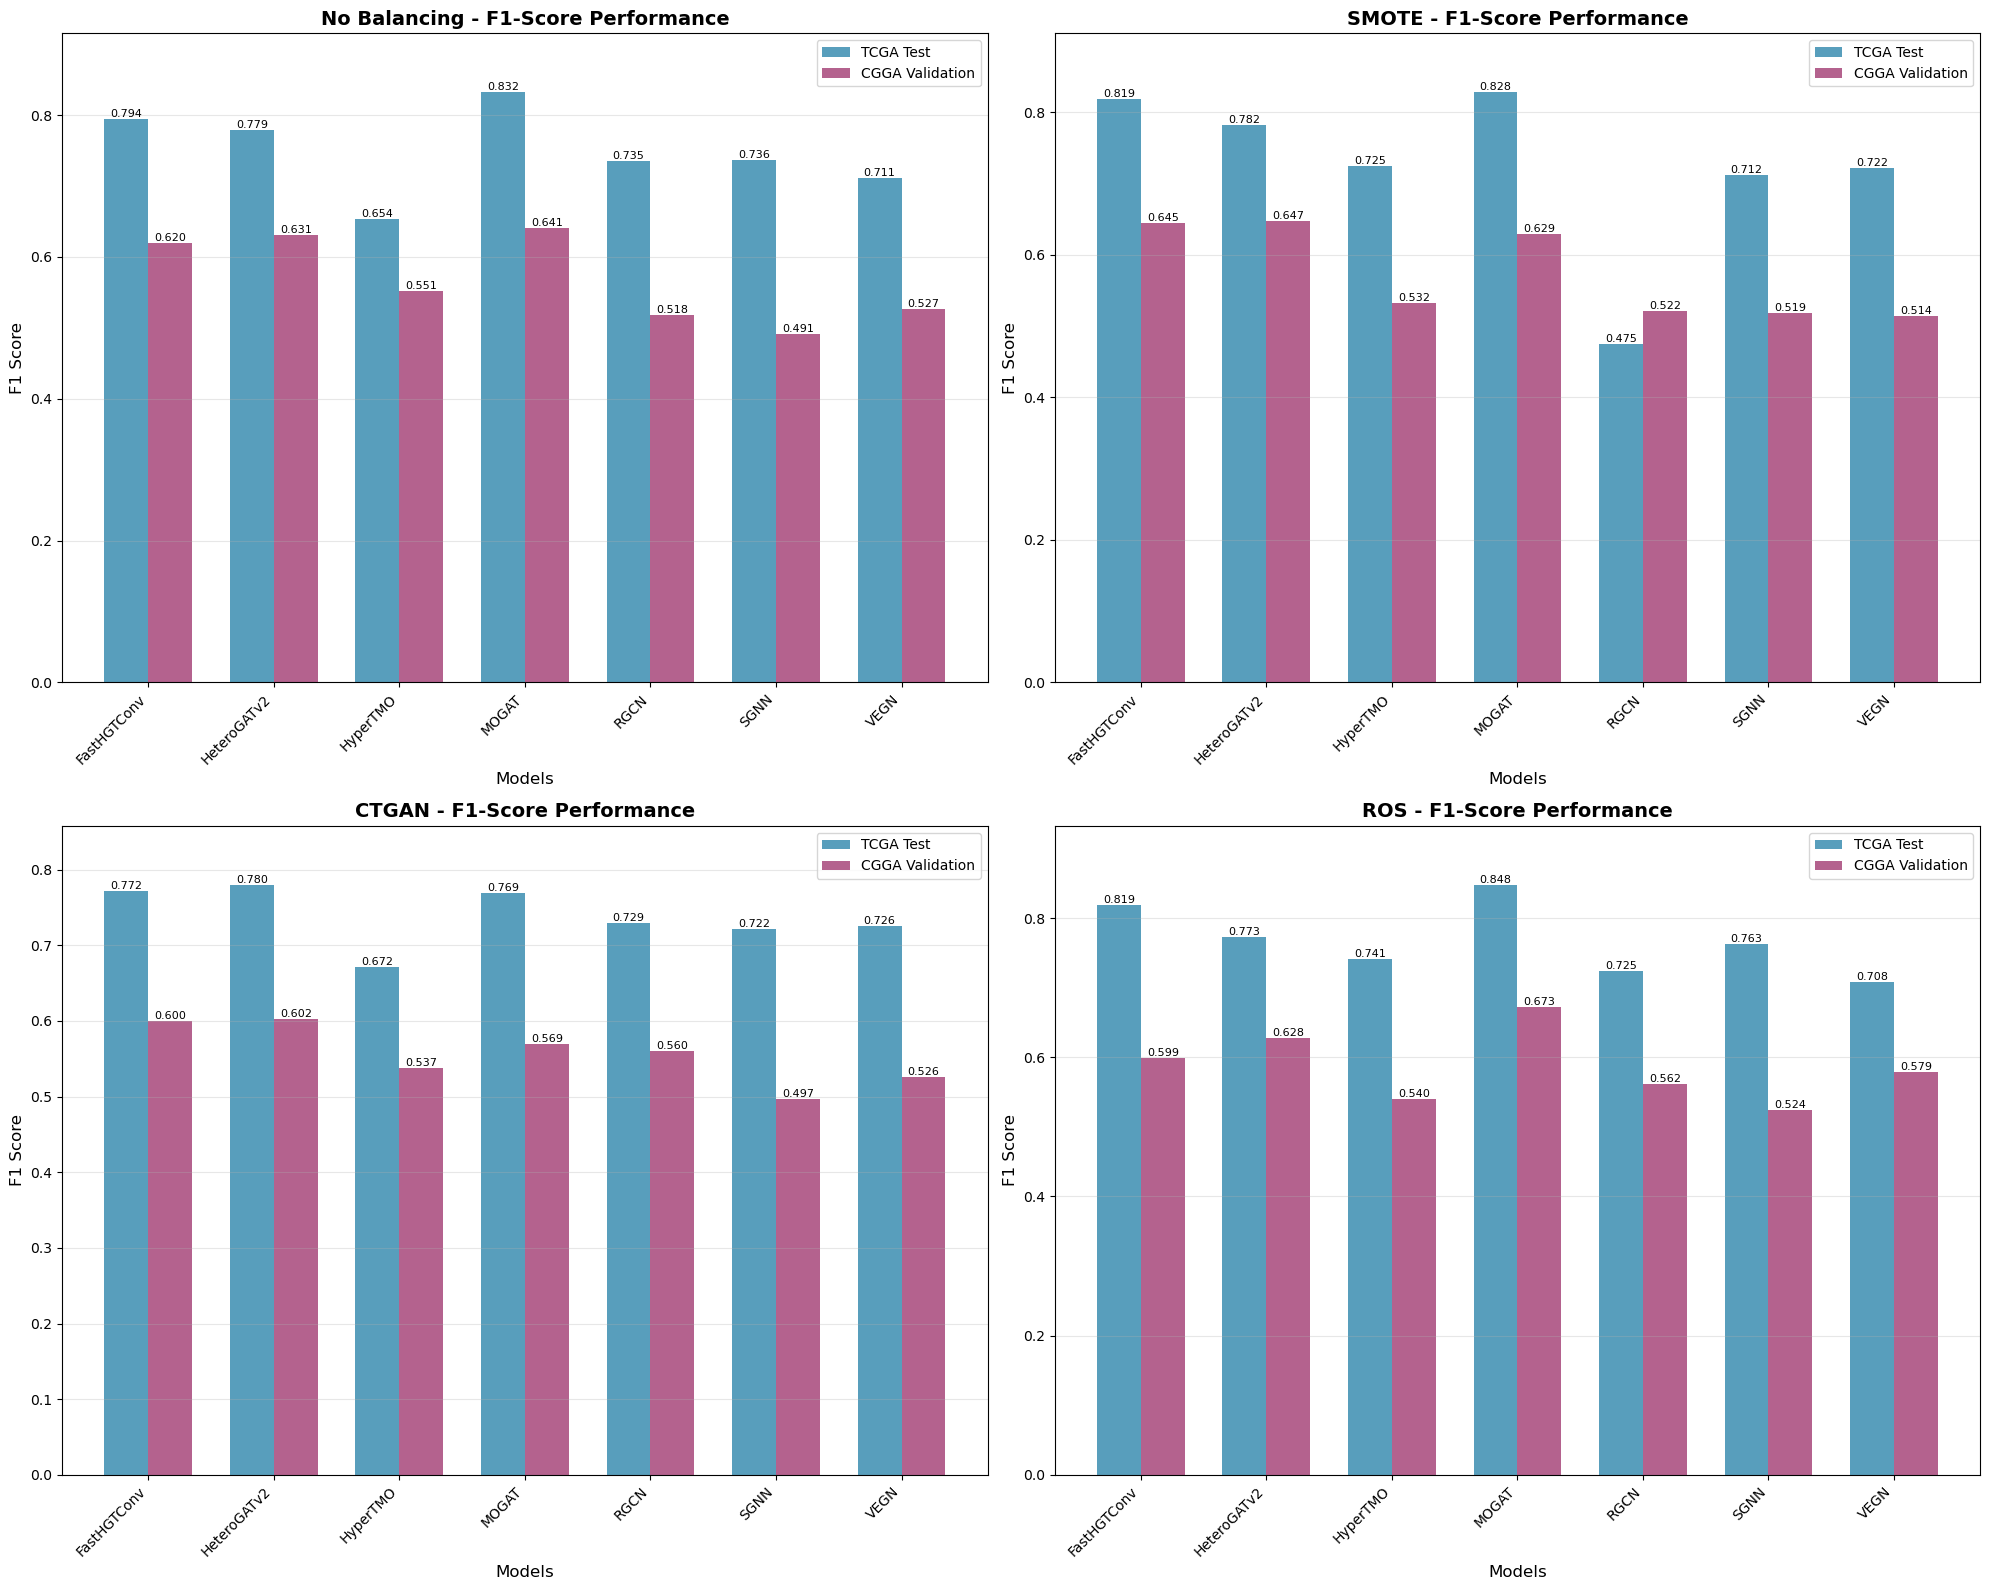


3. Plotting Accuracy comparison...


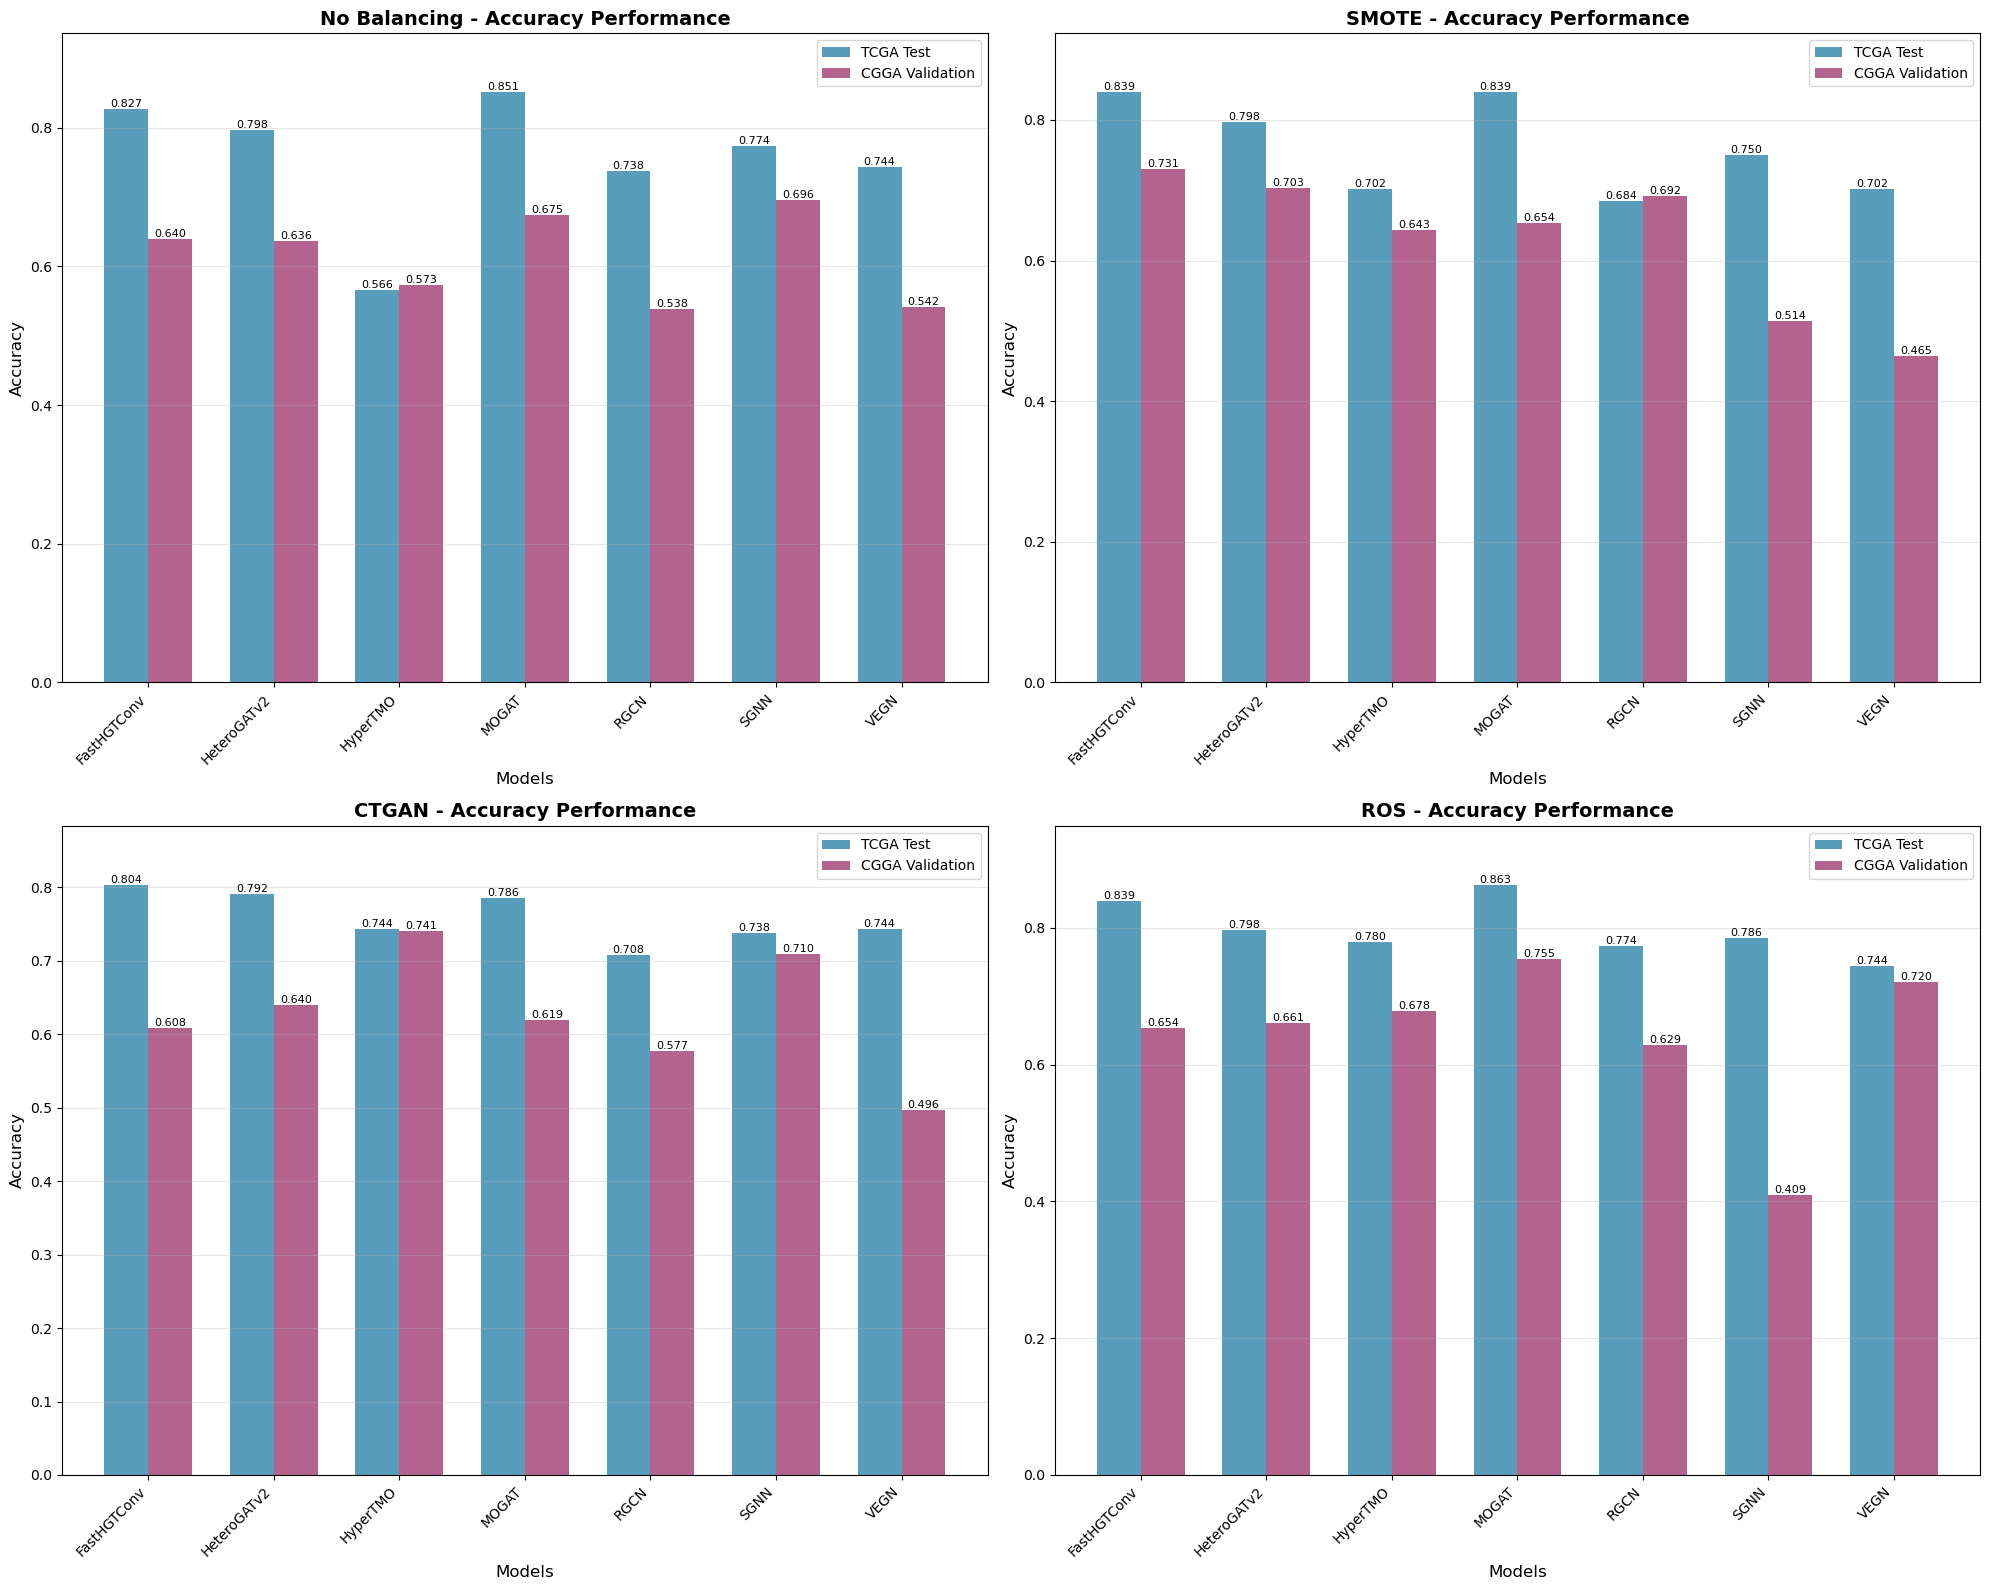


4. Plotting all pipelines for AUC...


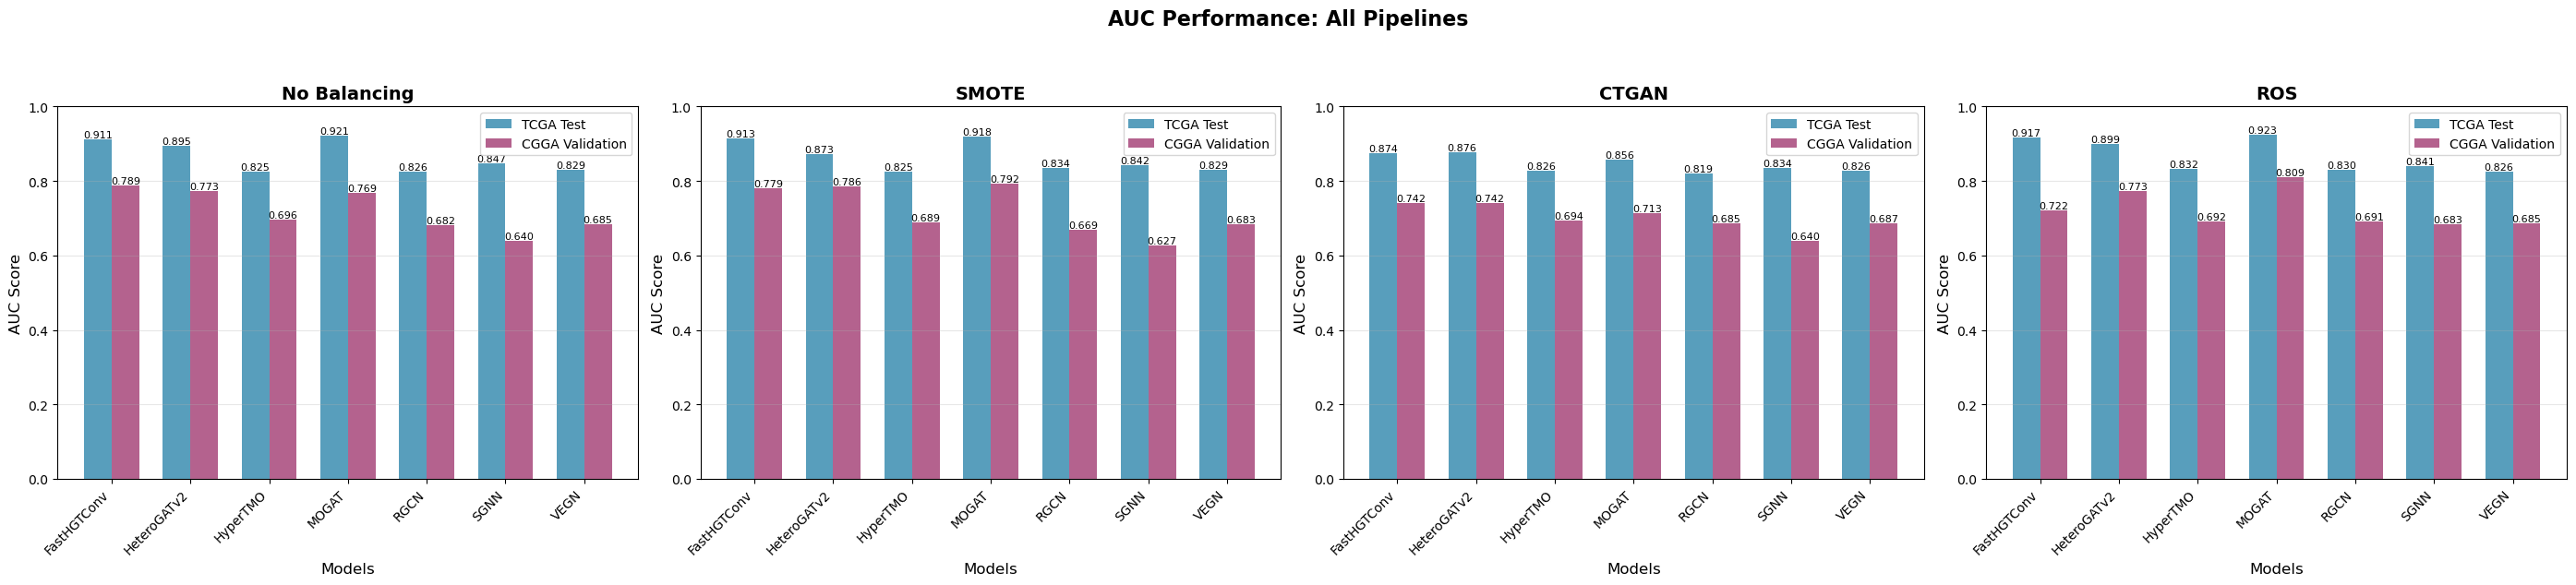


5. Creating summary statistics...

Summary Statistics (Mean ± Std):
                          AUC         Accuracy              F1        
                         mean     std     mean     std    mean     std
Model       Dataset                                                   
FastHGTConv CGGA       0.7578  0.0315   0.6582  0.0520  0.6161  0.0216
            TCGA Test  0.9040  0.0200   0.8274  0.0168  0.8011  0.0223
HeteroGATv2 CGGA       0.7687  0.0190   0.6600  0.0305  0.6273  0.0186
            TCGA Test  0.8856  0.0133   0.7961  0.0030  0.7786  0.0038
HyperTMO    CGGA       0.6925  0.0028   0.6591  0.0700  0.5403  0.0082
            TCGA Test  0.8270  0.0036   0.6979  0.0938  0.6981  0.0418
MOGAT       CGGA       0.7708  0.0418   0.6757  0.0578  0.6280  0.0434
            TCGA Test  0.9046  0.0322   0.8348  0.0342  0.8193  0.0344
RGCN        CGGA       0.6817  0.0095   0.6093  0.0667  0.5405  0.0238
            TCGA Test  0.8272  0.0065   0.7262  0.0386  0.6660  0.1273
SGNN    

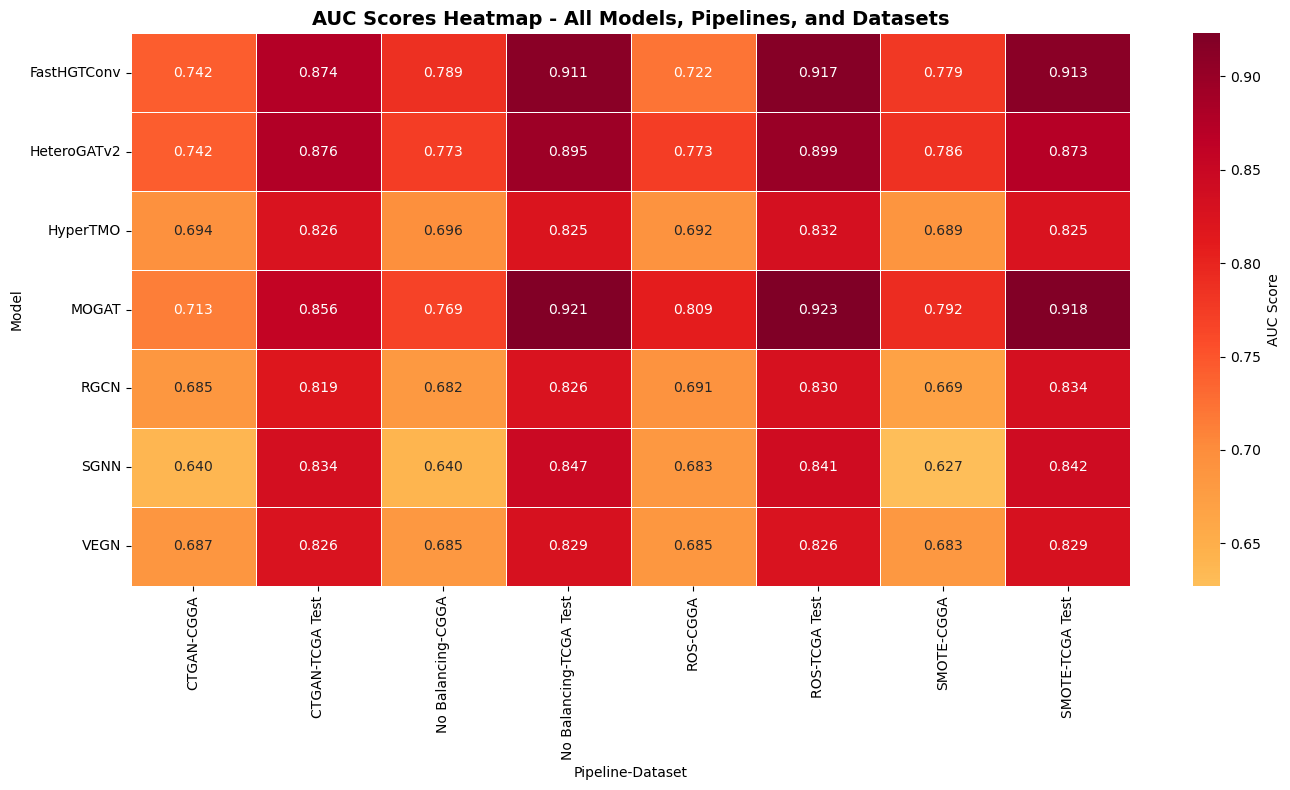


7. Finding best performing configurations...

Best AUC scores:
CGGA: MOGAT (ROS) - AUC: 0.8092
TCGA Test: MOGAT (ROS) - AUC: 0.9230

Best F1 scores:
CGGA: MOGAT (ROS) - F1: 0.6729
TCGA Test: MOGAT (ROS) - F1: 0.8477

Best Accuracy scores:
CGGA: MOGAT (ROS) - Accuracy: 0.7552
TCGA Test: MOGAT (ROS) - Accuracy: 0.8631

VISUALIZATION COMPLETE

Generated files:
1. auc_comparison.png - Grouped bar charts for AUC (separate for each pipeline)
2. f1_comparison.png - Grouped bar charts for F1-score (separate for each pipeline)
3. accuracy_comparison.png - Grouped bar charts for Accuracy (separate for each pipeline)
4. auc_all_pipelines.png - All pipelines together for AUC
5. auc_heatmap.png - Heatmap showing all AUC scores


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualization
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Read the CSV file
df = pd.read_csv('V15_results_final.csv')

# Display the first few rows to verify data
print("First few rows of the dataset:")
print(df.head())
print("\nDataset shape:", df.shape)
print("\nUnique models:", df['Model'].unique())
print("\nUnique pipelines:", df['Pipeline'].unique())

# Get unique models (7 models)
models = df['Model'].unique()
print("\nModels:", models)

# Create function to plot grouped bar chart for a given metric
def plot_metric_comparison(df, metric_name, title, ylabel, filename):
    """
    Create grouped bar chart comparing TCGA Test vs CGGA Validation for all models
    """
    # Filter data for TCGA Test and CGGA
    tcga_data = df[df['Dataset'] == 'TCGA Test'][['Model', 'Pipeline', metric_name]]
    cgga_data = df[df['Dataset'] == 'CGGA'][['Model', 'Pipeline', metric_name]]
    
    # Merge the data
    merged_data = pd.merge(tcga_data, cgga_data, on=['Model', 'Pipeline'], 
                          suffixes=('_TCGA', '_CGGA'))
    
    # Get unique pipelines
    pipelines = merged_data['Pipeline'].unique()
    
    # Set up the plot
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    # Define colors for TCGA and CGGA
    colors = ['#2E86AB', '#A23B72']  # Blue for TCGA, Purple for CGGA
    
    # Plot for each pipeline
    for idx, pipeline in enumerate(pipelines[:4]):  # Limit to first 4 pipelines if more
        pipeline_data = merged_data[merged_data['Pipeline'] == pipeline]
        
        # Sort by model for consistent ordering
        pipeline_data = pipeline_data.sort_values('Model')
        
        x = np.arange(len(pipeline_data))
        width = 0.35
        
        # Create bars
        bars1 = axes[idx].bar(x - width/2, pipeline_data[f'{metric_name}_TCGA'], 
                             width, label='TCGA Test', color=colors[0], alpha=0.8)
        bars2 = axes[idx].bar(x + width/2, pipeline_data[f'{metric_name}_CGGA'], 
                             width, label='CGGA Validation', color=colors[1], alpha=0.8)
        
        # Customize the plot
        axes[idx].set_xlabel('Models', fontsize=12)
        axes[idx].set_ylabel(ylabel, fontsize=12)
        axes[idx].set_title(f'{pipeline} - {title}', fontsize=14, fontweight='bold')
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(pipeline_data['Model'], rotation=45, ha='right')
        axes[idx].legend(loc='upper right')
        axes[idx].grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                              f'{height:.3f}', ha='center', va='bottom', fontsize=8)
        
        # Set y-axis limit with some padding
        axes[idx].set_ylim(0, max(pipeline_data[f'{metric_name}_TCGA'].max(), 
                                  pipeline_data[f'{metric_name}_CGGA'].max()) * 1.1)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Create function to plot all pipelines together for a given metric
def plot_all_pipelines_comparison(df, metric_name, title, ylabel, filename):
    """
    Create grouped bar chart with all pipelines for TCGA Test vs CGGA Validation
    """
    # Filter data
    tcga_data = df[df['Dataset'] == 'TCGA Test'][['Model', 'Pipeline', metric_name]]
    cgga_data = df[df['Dataset'] == 'CGGA'][['Model', 'Pipeline', metric_name]]
    
    # Merge the data
    merged_data = pd.merge(tcga_data, cgga_data, on=['Model', 'Pipeline'], 
                          suffixes=('_TCGA', '_CGGA'))
    
    # Get unique models and pipelines
    models = merged_data['Model'].unique()
    pipelines = merged_data['Pipeline'].unique()
    
    # Set up the plot
    n_pipelines = len(pipelines)
    fig, axes = plt.subplots(1, n_pipelines, figsize=(7*n_pipelines, 6))
    
    # Define colors
    colors = ['#2E86AB', '#A23B72']
    
    for idx, pipeline in enumerate(pipelines):
        pipeline_data = merged_data[merged_data['Pipeline'] == pipeline]
        pipeline_data = pipeline_data.sort_values('Model')
        
        x = np.arange(len(pipeline_data))
        width = 0.35
        
        # Create bars
        bars1 = axes[idx].bar(x - width/2, pipeline_data[f'{metric_name}_TCGA'], 
                             width, label='TCGA Test', color=colors[0], alpha=0.8)
        bars2 = axes[idx].bar(x + width/2, pipeline_data[f'{metric_name}_CGGA'], 
                             width, label='CGGA Validation', color=colors[1], alpha=0.8)
        
        # Customize
        axes[idx].set_xlabel('Models', fontsize=12)
        axes[idx].set_ylabel(ylabel, fontsize=12)
        axes[idx].set_title(f'{pipeline}', fontsize=14, fontweight='bold')
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(pipeline_data['Model'], rotation=45, ha='right')
        axes[idx].legend(loc='upper right')
        axes[idx].grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                              f'{height:.3f}', ha='center', va='bottom', fontsize=8)
        
        axes[idx].set_ylim(0, 1.0)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Create summary statistics
def create_summary_table(df):
    """
    Create summary table with mean and std for each metric
    """
    summary = df.groupby(['Model', 'Dataset']).agg({
        'AUC': ['mean', 'std'],
        'Accuracy': ['mean', 'std'],
        'F1': ['mean', 'std']
    }).round(4)
    
    return summary

# Main execution
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# 1. Plot AUC comparison
print("\n1. Plotting AUC comparison...")
plot_metric_comparison(df, 'AUC', 'AUC Performance', 'AUC Score', 'auc_comparison.png')

# 2. Plot F1-score comparison
print("\n2. Plotting F1-score comparison...")
plot_metric_comparison(df, 'F1', 'F1-Score Performance', 'F1 Score', 'f1_comparison.png')

# 3. Plot Accuracy comparison
print("\n3. Plotting Accuracy comparison...")
plot_metric_comparison(df, 'Accuracy', 'Accuracy Performance', 'Accuracy', 'accuracy_comparison.png')

# 4. Plot all pipelines together for AUC
print("\n4. Plotting all pipelines for AUC...")
plot_all_pipelines_comparison(df, 'AUC', 'AUC Performance: All Pipelines', 'AUC Score', 'auc_all_pipelines.png')

# 5. Create summary statistics
print("\n5. Creating summary statistics...")
summary = create_summary_table(df)
print("\nSummary Statistics (Mean ± Std):")
print(summary)

# 6. Create a heatmap for better visualization
print("\n6. Creating heatmap for AUC comparison...")
# Pivot data for heatmap
auc_pivot = df.pivot_table(values='AUC', index='Model', columns=['Pipeline', 'Dataset'], aggfunc='mean')
plt.figure(figsize=(14, 8))
sns.heatmap(auc_pivot, annot=True, fmt='.3f', cmap='YlOrRd', center=0.7, 
            linewidths=0.5, cbar_kws={'label': 'AUC Score'})
plt.title('AUC Scores Heatmap - All Models, Pipelines, and Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('auc_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Find best performing configurations
print("\n7. Finding best performing configurations...")
best_auc = df.loc[df.groupby('Dataset')['AUC'].idxmax()]
best_f1 = df.loc[df.groupby('Dataset')['F1'].idxmax()]
best_accuracy = df.loc[df.groupby('Dataset')['Accuracy'].idxmax()]

print("\nBest AUC scores:")
for _, row in best_auc.iterrows():
    print(f"{row['Dataset']}: {row['Model']} ({row['Pipeline']}) - AUC: {row['AUC']:.4f}")

print("\nBest F1 scores:")
for _, row in best_f1.iterrows():
    print(f"{row['Dataset']}: {row['Model']} ({row['Pipeline']}) - F1: {row['F1']:.4f}")

print("\nBest Accuracy scores:")
for _, row in best_accuracy.iterrows():
    print(f"{row['Dataset']}: {row['Model']} ({row['Pipeline']}) - Accuracy: {row['Accuracy']:.4f}")

print("\n" + "="*60)
print("VISUALIZATION COMPLETE")
print("="*60)
print("\nGenerated files:")
print("1. auc_comparison.png - Grouped bar charts for AUC (separate for each pipeline)")
print("2. f1_comparison.png - Grouped bar charts for F1-score (separate for each pipeline)")
print("3. accuracy_comparison.png - Grouped bar charts for Accuracy (separate for each pipeline)")
print("4. auc_all_pipelines.png - All pipelines together for AUC")
print("5. auc_heatmap.png - Heatmap showing all AUC scores")